# PEL 309 - Data Science - Paper

Esse arquivo contém as análises e experimentos correspondentes ao trabalho da matéria PEL 309.

In [1]:
import os
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, train_test_split

/home/melo/code/data-science/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Dataset

In [2]:
# internet caiu kkkkk

df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## Droping duplicates

In [3]:
df = df.drop_duplicates()

df.shape, df.columns, df.dtypes

((7500, 16),
 Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
        'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
        'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
        'stress_level', 'academic_work_impact', 'addiction_level',
        'addicted_label'],
       dtype='str'),
 transaction_id                 str
 user_id                        str
 age                          int64
 gender                         str
 daily_screen_time_hours    float64
 social_media_hours         float64
 gaming_hours               float64
 work_study_hours           float64
 sleep_hours                float64
 notifications_per_day        int64
 app_opens_per_day            int64
 weekend_screen_time        float64
 stress_level                   str
 academic_work_impact           str
 addiction_level                str
 addicted_label               int64
 dtype: object)

In [4]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## Removing Unused/Bad Columns

In [5]:
# If there is one entry per user, feel free to remove the column, it is not a series
if df['user_id'].nunique() == df.shape[0]:
    print("One entry per user")
    df = df.drop(columns=['transaction_id', 'user_id', 'addiction_level', 'weekend_screen_time'])
else:
    print("More than one entry per user")
    df = df.drop(columns=['transaction_id', 'addiction_level', 'weekend_screen_time'])

One entry per user


In [6]:
df.columns, df.dtypes

(Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
        'gaming_hours', 'work_study_hours', 'sleep_hours',
        'notifications_per_day', 'app_opens_per_day', 'stress_level',
        'academic_work_impact', 'addicted_label'],
       dtype='str'),
 age                          int64
 gender                         str
 daily_screen_time_hours    float64
 social_media_hours         float64
 gaming_hours               float64
 work_study_hours           float64
 sleep_hours                float64
 notifications_per_day        int64
 app_opens_per_day            int64
 stress_level                   str
 academic_work_impact           str
 addicted_label               int64
 dtype: object)

In [7]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,1.000000


## Testing and converting categorical variables

In [8]:
# Converting categorical columns to categorical data type
for column in ["gender", "stress_level", "academic_work_impact"]:
    print(df[column].value_counts())
    df[column] = df[column].astype("category")

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64


In [9]:
targets = df["addicted_label"]

features_df = df.drop(columns=["addicted_label"])

features_df.dtypes, targets.shape

(age                           int64
 gender                     category
 daily_screen_time_hours     float64
 social_media_hours          float64
 gaming_hours                float64
 work_study_hours            float64
 sleep_hours                 float64
 notifications_per_day         int64
 app_opens_per_day             int64
 stress_level               category
 academic_work_impact       category
 dtype: object,
 (7500,))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(features_df, targets, test_size=.3, random_state=42)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5250, 11), (2250, 11), (5250,), (2250,))

In [12]:
y_train.value_counts(), y_test.value_counts()

(addicted_label
 1    3731
 0    1519
 Name: count, dtype: int64,
 addicted_label
 1    1577
 0     673
 Name: count, dtype: int64)

# Preprocessing + Classification Pipelines

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [14]:
X_train.select_dtypes(include=['number']).head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day
7179,35,3.92,2.34,0.12,1.44,6.01,163,165
6054,34,6.21,2.24,0.59,4.72,4.74,44,41
7269,31,7.33,4.09,1.25,3.79,6.82,234,101
4866,20,4.42,5.05,2.17,5.74,7.95,211,80
3593,32,6.63,2.03,0.48,4.21,6.24,89,154


In [15]:
# separating categorical data from numeric and encoding using dummy encoding (one hot) in the pipeline

X_train.select_dtypes(include=['category']).head()

,gender,stress_level,academic_work_impact
7179,Male,Low,Yes
6054,Female,Low,No
7269,Female,Low,Yes
4866,Female,Medium,Yes
3593,Other,High,No


In [16]:
numeric_features = X_train.select_dtypes(include=['number']).columns
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_features = X_train.select_dtypes(include=['category']).columns
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selector(dtype_exclude="category")),
        ("cat", categorical_transformer, selector(dtype_include="category")),
    ]
)

In [17]:
classifiers = {
    "LogisticRegression": LogisticRegression(),
    "MLPClassifier": MLPClassifier(),
    "RandomForestClassifier": RandomForestClassifier(random_state=0),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "XGBClassifier": XGBClassifier()
}

In [18]:
results = []

for key, clf_model in classifiers.items():
    clf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf_model)
        ]
    )
    clf.fit(X_train, y_train)
    y_hat = clf.predict(X_test)
    
    results.append({
        "clf_name": key,
        "clf": clf,
        "confusion_matrix": confusion_matrix(y_test, y_hat),
        "accuracy_score": accuracy_score(y_test, y_hat),
        "f1_score": f1_score(y_test, y_hat),
        "precision_score": precision_score(y_test, y_hat),
        "recall_score": recall_score(y_test, y_hat)

    })

/home/melo/code/data-science/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
results_df = pd.DataFrame(results).drop(columns=["clf"])

results_df

,clf_name,confusion_matrix,accuracy_score,f1_score,precision_score,recall_score
0,LogisticRegression,"[[536, 137], [110, 1467]]",0.890222,0.922351,0.914589,0.930247
1,MLPClassifier,"[[583, 90], [88, 1489]]",0.920889,0.943599,0.943002,0.944198
2,RandomForestClassifier,"[[632, 41], [117, 1460]]",0.929778,0.948668,0.972685,0.925808
3,GradientBoostingClassifier,"[[625, 48], [113, 1464]]",0.928444,0.947880,0.968254,0.928345
4,XGBClassifier,"[[615, 58], [97, 1480]]",0.931111,0.950241,0.962289,0.938491


In [20]:
df_importance = pd.DataFrame([{"feature_name": name, "importance": imp} for imp, name in zip(results[2]["clf"]["classifier"].feature_importances_, X_train.columns)])

In [21]:
df_importance = df_importance.sort_values(by="importance", ascending=False)

<Axes: xlabel='importance', ylabel='feature_name'>

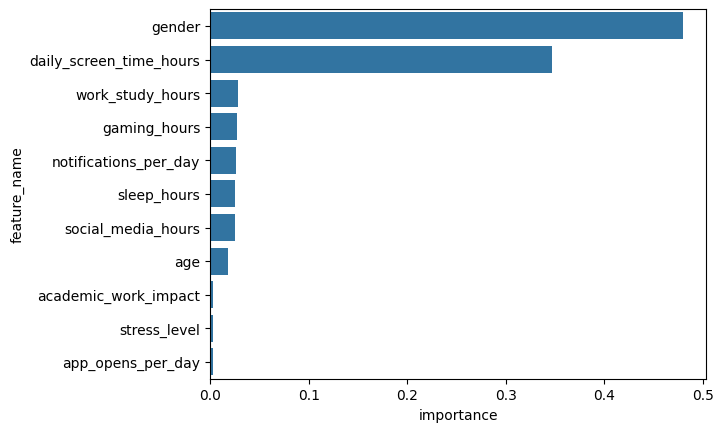

In [22]:
sns.barplot(data=df_importance, x="importance", y="feature_name")

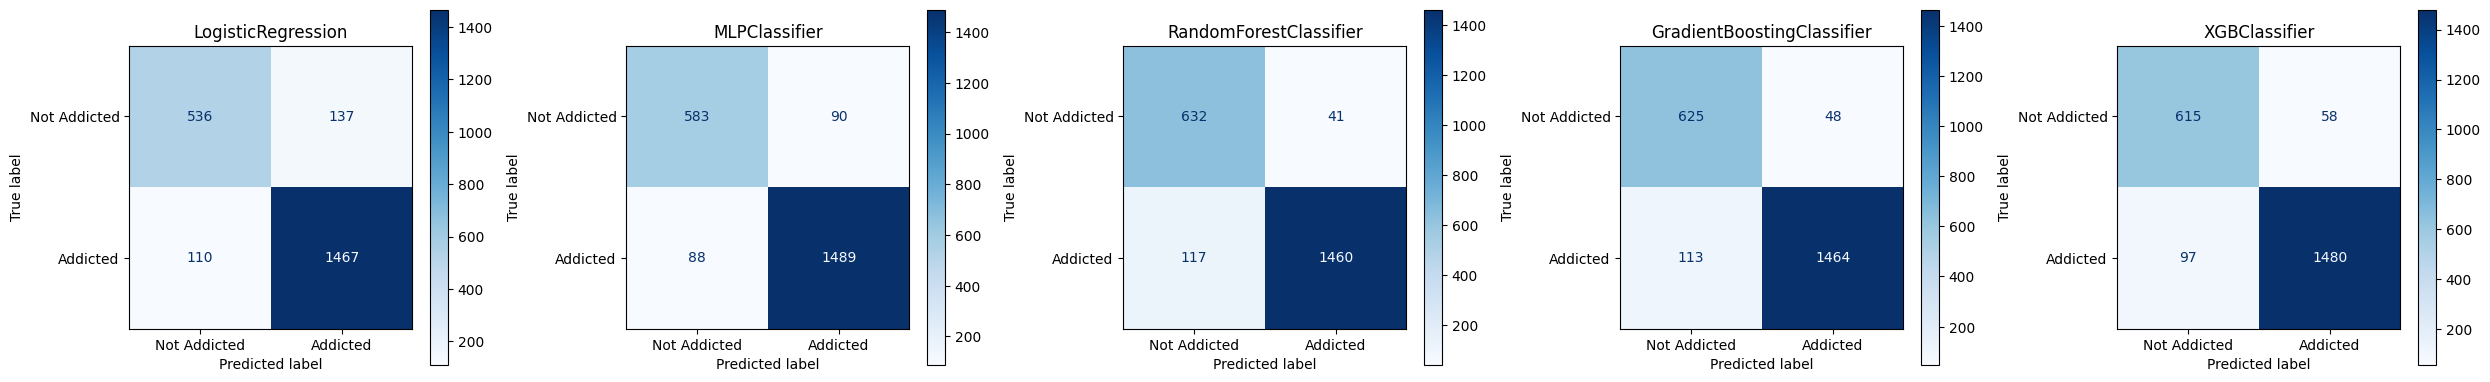

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

rows = 2
columns = 3

f, axes = plt.subplots(1, 5, figsize=(25, 4))

for i in range(len(results_df["confusion_matrix"])):

    ConfusionMatrixDisplay(confusion_matrix=results_df["confusion_matrix"][i], display_labels=["Not Addicted", "Addicted"]).plot(ax=axes[i], cmap="Blues")
    axes[i].title.set_text(results_df["clf_name"][i])
    plt.tight_layout()
